<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/TP2_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRABAJO PRÁCTICO DE CLUSTERING: CONSIGNAS

**Fernando Javier García Liévano**

## Utilizando solo Numpy y Scikit-learn, y opcionalmente Pandas y Matplotlib, debes realizar  lo siguiente sobre el conjunto de datos de California Housing:




### Instalación de librerías

In [29]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

### Utils y variables

In [2]:
def print_heading(title: str):
    line = "=" * 90
    print(line)
    print(f" 🟦 {title.upper()}")
    print(line)
    print("\n")

## 1. Analiza los datos, inspecciona todas las características y el target.

**Explica de que trata el dataset, cada una de sus variables**

**Asegúrate de preparar los datos para utilizarse en modelos  predictivos.**

**Puedes hacer el preprocesamiento de características  (selección, transformación) que consideres más adecuado, justificar.**

Fuente del dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices

### 1.1 Carga del dataset y vista general

In [3]:
# Descarga la última versión del dataset
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [4]:
! ls /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1

ls: cannot access '/root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1': No such file or directory


In [5]:
files_in_path = os.listdir(path)
print(f"--> Archivos en el directorio {path}: {files_in_path}. \n")
ruta_al_archivo = path + "/" +files_in_path[0]

print(f"--> Cargando datos desde : {ruta_al_archivo}.\n")
df = pd.read_csv(ruta_al_archivo)

print("--> DataFrame 'df' creado. Muestro las primeras 5 filas: \n")
display(df.head())


--> Archivos en el directorio /kaggle/input/california-housing-prices: ['housing.csv']. 

--> Cargando datos desde : /kaggle/input/california-housing-prices/housing.csv.

--> DataFrame 'df' creado. Muestro las primeras 5 filas: 



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
print_heading('Analizamos forma e información del dataset')
df.info()

 🟦 ANALIZAMOS FORMA E INFORMACIÓN DEL DATASET


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


> ℹ El dataset cuenta con 2,0640 filas y con 10 columnas. Tenemos a `ocean_proximity` como única variable categórica y el resto son numéricas. Y podemos notar que en la variable `total_bedrooms` tenemos valores faltantes.

### 1.2 Descripción del Dataset

**¿De qué trata el Dataset?**

El dataset en general nos da información sobre las casas ubicadas en distritos de California. Una cosa a tener en cuenta es que el dataset no nos da información sobre casas individuales, sino de bloques de casas.

Entre las variables del dataset tenemos: coordenadas geográficas, cantidad total de habitaciones y dormitorios por bloque, población, media de ingresos de los hogares, media de valores de las viviendas y proximidad al océano.


**Inspeccionamos las características**

- **longitude** y **latitude**: coordenadas geográficas correspondientes a cada bloque de casas.
- **housing_median_age**: mediana de antigüedad de las casas en un bloque.
- **total_rooms**: número total de habitaciones en un bloque.
- **total_bedrooms**: número total de dormitorios en un bloque.
- **population**: número total de personas que residen en un bloque de casas.
- **households**: número total de hogares, es decir, casas ocupadas dentro del bloque.
- **median_income**: ingreso mediano de las casas en el bloque.
- **median_house_value**: valor mediano de las casas del bloque.
- **ocean_proximity**: variable categórica que indica la cercanía del bloque de casas al océano.

> ℹ Todas son variables numéricas, salvo `ocean_proximity` que es categórica

### 1.3 Análisis exploratorio

**1.3.1 Análisis de nulos**

In [7]:
print_heading('Cantidad de nulos por columna')
print(df.isnull().sum())
print('-' * 90)

null_percentage = ((df['total_bedrooms'].isnull().mean()) * 100).round(2)

print(f"\n -> La única columna con nulos es 'total_bedrooms, con 207 valores faltantes, \n lo que representa un {null_percentage}% del dataset.")

 🟦 CANTIDAD DE NULOS POR COLUMNA


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
------------------------------------------------------------------------------------------

 -> La única columna con nulos es 'total_bedrooms, con 207 valores faltantes, 
 lo que representa un 1.0% del dataset.


> ℹ 1% de +20k registros es un porcentaje poco significante, pero para evitar perder información vamos a imputar con la mediana.

**1.3.2 Resumen Estadístico**

In [8]:
stats = df.describe().T
stats.rename(columns={'50%': 'median'}, inplace=True) # renombro para que sea más fácil de identificar la mediana
stats.round(2)

,count,mean,std,min,25%,median,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


> ℹ Al analizar los estadísticos, se identificó la posible presencia de outliers en la variable `total_rooms`, podemos notarlo en la brecha que hay entre la media y la mediana, y además viendo la distancia entre el valor máximo y el tercer cuartil.


**1.3.3 Distribución de variables**

 🟦 DISTRIBUCIÓN DE VARIABLES CLAVE




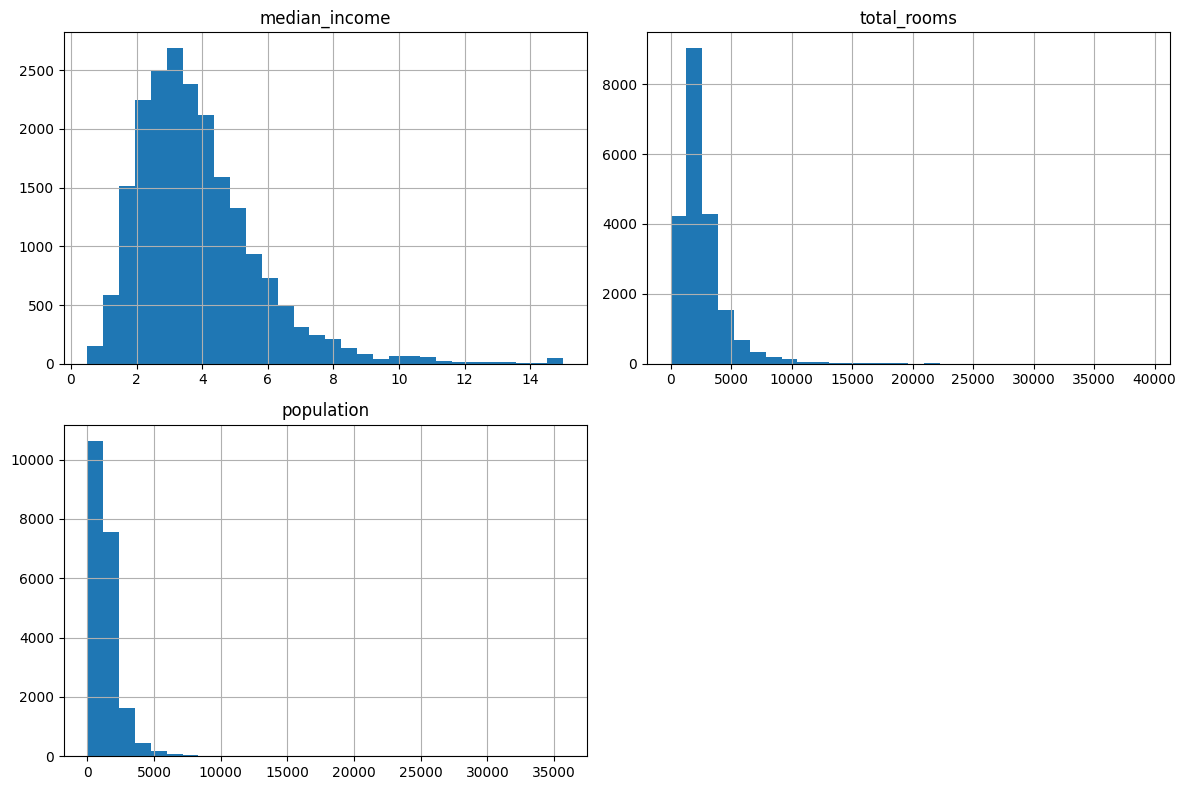

In [9]:
print_heading('Distribución de variables clave')

cols = ['median_income', 'total_rooms', 'population']

df[cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

> ℹ Se seleccionaron `median_income`, `total_rooms` y `population` por ser variables que representan aspectos importantes de dataset: economía, estructura y demografía, lo que nos va a permitir entender mejor el dataset y observar patrones en la distribución de los datos.
>
> Podemos observar asimetría positiva en las variables con presencia de algunos valores extremos principalmente en `total_rooms` y `population`.

**1.3.4 Escala de variables**

> ℹ Algunas variables presentan diferentes órdenes de magnitud (comparando `median_income` con `total_rooms`). Si no se llegara a aplicar escalado, esto sería un problema ya que sesgaría la formación de los clusters.

**1.3.5 Relación entre variables**

 🟦 RELACIÓN ENTRE VARIABLES




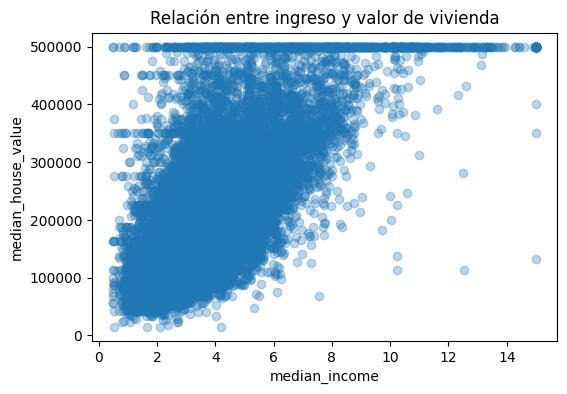

In [10]:
print_heading('Relación entre variables')

plt.figure(figsize=(6,4))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.title('Relación entre ingreso y valor de vivienda')
plt.show()

> ℹ En el gráfico podemos apreciar que hay una **relación positiva** entre el ingreso medio y el valor de vivienda. Pero, existe dispersión en los datos, lo que nos dice que hay otras variables influyendo en la determinación del precio.
>
> Otro detalle a tener en cuenta es que existe un límite superioren los valores de las casas, puede llegar a influir en el análisis.

### 1.4 Preprocesamiento de datos

**1.4.1 Tratamiento de valores faltantes**

Durante la exploración de datos detectamos un 1% de valores faltantes en la columna `total_bedrooms`. Dado que el porcentaje de datos faltantes es muy bajo, se decidió imputarlos utilizando la mediana, ya que nos ayuda a minimizar el impacto en la distribución de la variable.*texto en cursiva*

In [11]:
print_heading('Tratamiento de nulos')

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df.isnull().sum()

 🟦 TRATAMIENTO DE NULOS




,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


> ℹ Se verificó y se confirmó que no quedan valores faltantes en el dataset

**1.4.2 Selección de variables**

Durante esta etapa seleccionamos las variables a utilizar para el análisis.

Para comenzar, vamos a descartar la variable categórica `ocean_proximity` que será transformada posteriormente para poder ser incluida en el modelo. Ya que los algoritmos de clustering trabajan con distancias, vamos a priorizar las variables numéricas.

Por otro lado, la variable `median_house_value` no será utilizada para el entrenamiento ya que no se trata de un problema supervisado.



**1.4.3 Transformación de variables numéricas**

A partir de anáisis exploratorio se observó que algunas variables presentan cierto nivel de sesgo, principalmente las variables relacionadas con conteos, como `total_rooms`, `total_bedrooms`, `population` y `households`.

Para reducir la asimetría presentada, vamos a aplicar transformación logarítmica sobre dichas variables, lo que permite suavizar los valores extremos y así mejorar la distribución de los datos.



In [12]:
print_heading('Calculando transformación logarítmica de variables')

# calcular las transformaciones logarítmicas y guardarlas en series temporales
# np.log1p para manejar ceros (si los hubiera)
total_rooms_log_series = np.log1p(df['total_rooms'])
total_bedrooms_log_series = np.log1p(df['total_bedrooms'])
population_log_series = np.log1p(df['population'])
households_log_series = np.log1p(df['households'])

display(pd.DataFrame({
    'total_rooms_log': total_rooms_log_series,
    'total_bedrooms_log': total_bedrooms_log_series,
    'population_log': population_log_series,
    'households_log': households_log_series
}).head().round(2))

 🟦 CALCULANDO TRANSFORMACIÓN LOGARÍTMICA DE VARIABLES




,total_rooms_log,total_bedrooms_log,population_log,households_log
0,6.78,4.87,5.78,4.84
1,8.87,7.01,7.78,7.04
2,7.29,5.25,6.21,5.18
3,7.15,5.46,6.33,5.39
4,7.40,5.64,6.34,5.56


**1.4.4 Codificación de variables categóricas**

Se procederá a tratar la variable `ocean_proximity` mediante One-Hot Encoding  para que pueda ser tratada por los algoritmos de clustering, ya que al ser una variable categórica no tiene una representación numérica válida.



In [13]:
print_heading('Calculando One-Hot Encoding para ocean_proximity')

# instancia del OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# ajustar y transformar la columna 'ocean_proximity'
ocean_proximity_encoded = ohe.fit_transform(df[['ocean_proximity']])

# crear un DataFrame con las columnas codificadas
ocean_proximity_df = pd.DataFrame(
    ocean_proximity_encoded,
    columns=ohe.get_feature_names_out(['ocean_proximity']),
    index=df.index
)

print("-> One-Hot Encoding calculado para 'ocean_proximity'")
display(ocean_proximity_df.head())

 🟦 CALCULANDO ONE-HOT ENCODING PARA OCEAN_PROXIMITY


-> One-Hot Encoding calculado para 'ocean_proximity'


,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0


**1.4.5 Escalado de variables**

El escalado de variables es esencial en algoritmos basados en la distancia como K-means. Al aplicar StandardScaler, nos aseguramos de que todas las características contribuyan equitativamente a la formación de los clústeres, evitando que variables con rangos mayores dominen indebidamente el cálculo de distancias.

In [14]:
print_heading('Creando dataFrame de características X y aplicamos escalado')

# columnas numéricas originales de df a incluir directamente en X
numerical_features = [
    'longitude', 'latitude', 'housing_median_age', 'median_income'
]

# crear el DataFrame X inicial con las características numéricas originales
X = df[numerical_features].copy()

# añadir las variables logarítmicas calculadas previamente como nuevas columnas en X
X['total_rooms_log'] = total_rooms_log_series
X['total_bedrooms_log'] = total_bedrooms_log_series
X['population_log'] = population_log_series
X['households_log'] = households_log_series

# concatenar las columnas One-Hot Encoded de ocean_proximity_df a X
X = pd.concat([X, ocean_proximity_df], axis=1)

# inicializamos el escalador
scaler = StandardScaler()

# aplicamos el escalado a todas las columnas en X
X_scaled_array = scaler.fit_transform(X)

# convertimos el array escalado de nuevo a un DataFrame, manteniendo los nombres de las columnas
X = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

print("-> DataFrame 'X' creado con las características seleccionadas, transformadas y escaladas.")
display(X.head())

print(f"\n->  Forma de X: {X.shape}")

 🟦 CREANDO DATAFRAME DE CARACTERÍSTICAS X Y APLICAMOS ESCALADO


-> DataFrame 'X' creado con las características seleccionadas, transformadas y escaladas.


,longitude,latitude,housing_median_age,median_income,total_rooms_log,total_bedrooms_log,population_log,households_log,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,2.344766,-1.131133,-1.642192,-1.694943,-1.569395,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
1,-1.322844,1.043185,-0.607019,2.332238,1.651357,1.320043,1.030337,1.449251,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
2,-1.332827,1.038503,1.856182,1.782699,-0.450310,-1.110094,-1.109604,-1.104849,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
3,-1.337818,1.038503,1.856182,0.932968,-0.638257,-0.817506,-0.949925,-0.813343,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
4,-1.337818,1.038503,1.856182,-0.012881,-0.312370,-0.576140,-0.933021,-0.583469,-0.891156,-0.681889,-0.015566,2.830742,-0.384466



->  Forma de X: (20640, 13)


## 2. Realiza un clustering sobre los datos con K-means, separándolos en un número manejable de  grupos (de 2 a 10).

2.1) Justifica cuál métrica ( o grupo de métricas) utilizas para determinar el valor de k.

2.2) Realiza un análisis descriptivo de cada clúster, grafica para cada uno diagrama cajas.

### 2.1 Determinación del número de clusters (k)

Para determinar el mejor k vamos a utilizar el método del codo ya que nos va a permitir analizar como varía la inercia según aumenta el número de grupos. Este método consiste en identificar el punto a partir del cual la mejora en la inercia deja de ser significativa.

Además, utilizamos el coeficiente de silueta como métrica complementaria ya que nos va a permitir evaluar la calidad de los clusters considerando la separación y cohesión de los mismos.

In [15]:
# rango de valores de k a evaluar
k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)

    # calcular el coeficiente de silueta
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

Visualizamos los gráficos de cada método

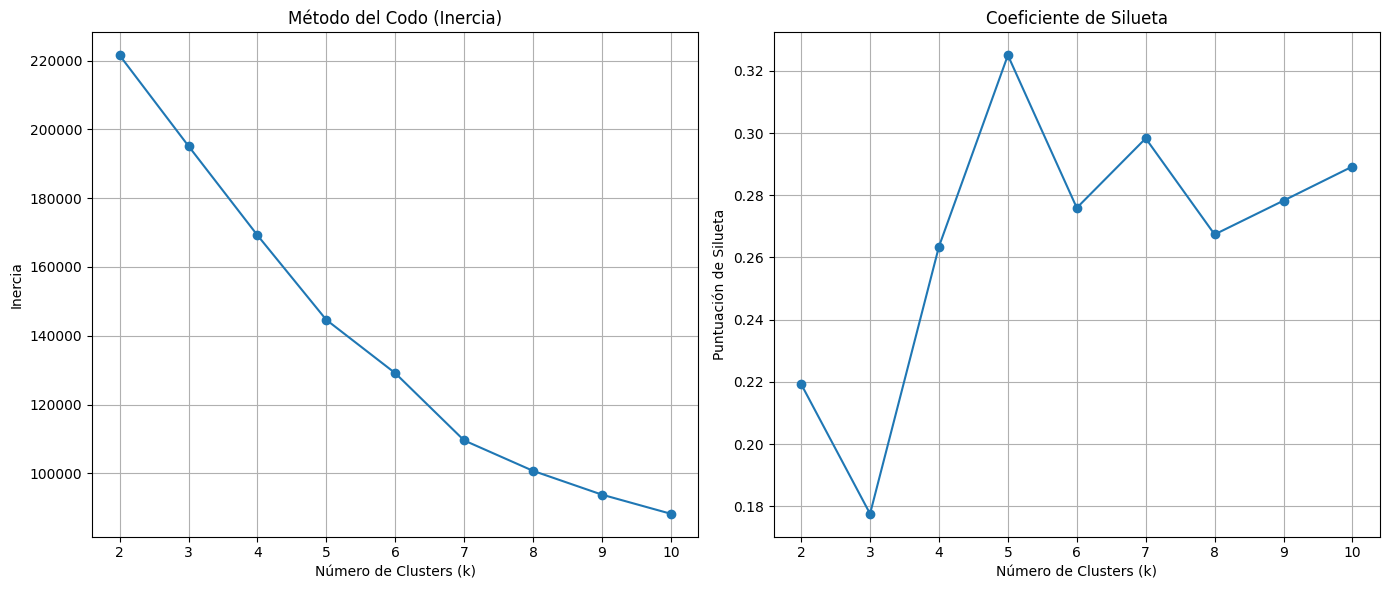

In [16]:
# gráfico del Método del Codo
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True)

# gráfico del Coeficiente de Silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Coeficiente de Silueta')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

> ℹ Analizando los gráficos, podemos notar que:
> - En el gráfico correspondiente al método de codo, a partir de k=5 la inercia disminuye a un ritmo menor.
> - En el gráfico del coeficiente de silueta, vemos que el valor más alto está en k=5.
>
> **Entonces, según el método del codo y el coeficiente de silueta, k=5 es nuestro mejor valor**

### 2.2 Análisis de los clusters

Una vez entrenado el modelo K-means con el valor de k seleccionado (5), analizamos las características de cada cluster.

In [17]:
best_k = 5

In [18]:
print_heading(f'Realizando K-Means con k={best_k}')

# inicializar y entrenar el modelo K-Means con el k óptimo
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_model.fit(X)

# agregamos la columna cluster al dataset
df['cluster'] = kmeans_model.labels_

print(f"-> K-Means completado. Se han asignado {best_k} clusters. \n")

 🟦 REALIZANDO K-MEANS CON K=5


-> K-Means completado. Se han asignado 5 clusters. 



In [19]:
print_heading('Vista aleatoria del dataset con clusters asignados')
df.sample(10)

 🟦 VISTA ALEATORIA DEL DATASET CON CLUSTERS ASIGNADOS




,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,cluster
2554,-124.18,40.78,33.0,1076.0,222.0,656.0,236.0,2.5096,72200.0,NEAR OCEAN,4
1351,-121.94,38.03,27.0,1654.0,478.0,1141.0,420.0,1.4871,87100.0,INLAND,1
11767,-121.28,38.74,33.0,4384.0,778.0,1775.0,789.0,4.0500,134700.0,INLAND,1
15735,-122.43,37.78,26.0,3587.0,1034.0,1821.0,936.0,2.6392,287500.0,NEAR BAY,2
16246,-121.27,37.98,43.0,2608.0,516.0,1322.0,528.0,2.5714,70000.0,INLAND,1
11293,-117.93,33.79,34.0,3592.0,616.0,2138.0,605.0,5.2129,193400.0,<1H OCEAN,3
263,-122.20,37.77,43.0,2430.0,502.0,1537.0,484.0,2.8980,121400.0,NEAR BAY,2
820,-122.07,37.63,24.0,2329.0,465.0,1401.0,453.0,4.5913,177600.0,NEAR BAY,2
11740,-121.12,38.86,17.0,3949.0,717.0,1683.0,686.0,3.3802,216500.0,INLAND,1
7811,-118.10,33.89,36.0,769.0,142.0,498.0,137.0,4.7159,182100.0,<1H OCEAN,0


**2.2.1 Análisis descriptivo**

Ahora asignados los clusters, realizamos un análisis descriptivo con el objetivo de identificar las características principales de cada grupo. Para ello, se agrupan los datos según el cluster y se calculan medidas estadísticas como la media (o mediana) de cada variable.

In [20]:
# excluyo variables categóricas para evitar error de python
df.groupby('cluster').mean(numeric_only=True).round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
cluster,,,,,,,,,
0,-119.85,36.23,30.71,546.11,117.31,323.07,99.78,3.51,178393.03
1,-119.71,36.70,23.66,3024.82,592.17,1545.69,532.28,3.23,124260.13
2,-122.26,37.80,37.77,2583.21,531.74,1272.82,506.01,4.17,259855.20
3,-118.82,34.54,29.07,2751.97,570.48,1589.36,541.75,4.24,240623.99
4,-119.30,34.71,29.21,2688.01,558.90,1404.40,521.24,4.00,249709.61


> Se observa que el **cluster 2** agrupa bloques de casas con mayor ingreso medio y mayor valor de vivienda. Por otro lado, el **cluster 1** concentra zonas con menor ingreso y menor valor de vivienda, sugiriendo que son zonas más económicas y más pobladas.
>
> Asimismo, el cluster 0 parece corresponder a regiones con menor cantidad de viviendas y población, posiblemente zonas menos urbanizadas, pero no puede confirmarse sin analizar `ocean_proximity`.
>
>Finalmente los clusters 3 y 4 presentan características intermedias, sugiriendo que representan sectores de clase media y media-alta.

In [21]:
# .unstack() pasa el segundo nivel del índice a columnas para ver la tabla horizontal,
# y fill_value=0 para reemplazar los NaN por 0s
df.groupby('cluster')['ocean_proximity'] \
  .value_counts() \
  .unstack(fill_value=0)

ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
cluster,,,,,
0,505,833,5,90,120
1,4,5717,0,0,0
2,1,0,0,2200,0
3,8626,1,0,0,0
4,0,0,0,0,2538


> ℹ Observamos que varios cluster presentan una fuerte correspondencia con la variable `ocean_proximity`. En particular, algunos clusters están claramente dominados por una única categoría geográfica, como zonas inland, cercanas a la bahía o cercanas al océano. Esto sugiere que la ubicación geográfica es un factor determinante en la segmentación realizada por el modelo.
>
> Hasta ahora, podemos decir que:
> - Zonas cercanas a la bahía = Ingresos y valor de vivienda altos.
> - El cluster 0 parece el único que no está bien definido geográficamente, lo que sugiere que está dominado por otra variable.
> - La ubicación es una variable clave en el clustering.

**2.2.2 Boxplots por cluster**

Para complementar al análisis descriptivo, visualizamos la distribución de algunas variables relevantes mediante diagramas de caja, lo que permite observar la dispersión y posibles outliers dentro de cada cluster.

 🟦 MEDIANA DE INGRESOS




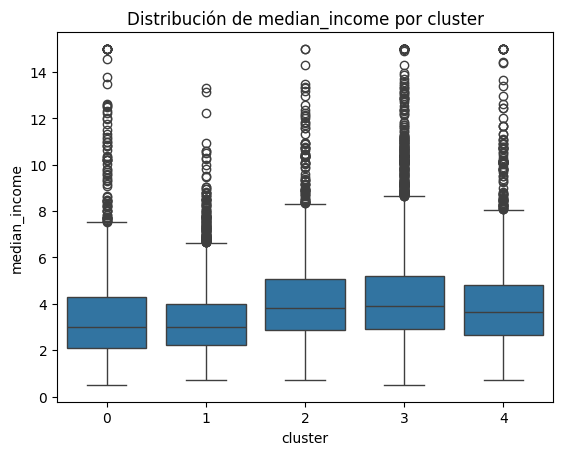

In [22]:
features = ['median_income', 'median_house_value', 'population']

print_heading('Mediana de ingresos')

plt.figure()
sns.boxplot(x='cluster', y='median_income', data=df)
plt.title(f'Distribución de median_income por cluster')
plt.show()

> ℹ Observamos que los clusters presentan diferencias en la distribución del ingreso medio. En particular, el cluser 1 muestra los valores más bajos, mientras que los clusters 2 y 3 concentran los ingresos más altos.
>
> Cabe destacar la presencia de outliers en todos los grupos, lo que indica que el ingreso no es el único factor importante en la segmentación de los clusters.

 🟦 MEDIANA DE VALOR DE VIVIENDA




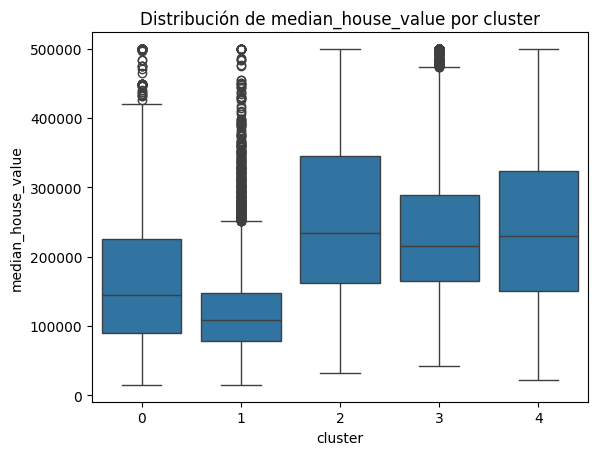

In [23]:
print_heading('Mediana de valor de vivienda')

plt.figure()
sns.boxplot(x='cluster', y='median_house_value', data=df)
plt.title(f'Distribución de median_house_value por cluster')
plt.show()

> ℹ Se observa una clara diferenciación en el valor de vivivenda entre los clusters.
>
>El cluster 1 presenta los valores más bajos, mientras que 2, 3 y 4 los valores más altos. Los clusters asociados a zonas cercanas al agua muestran mayores valores de vivienda, lo que sugiere una fuerte relación entre ubicación geográfica y precio.
>
> Pero, se observa cierto nivel de solapamiento entre los clusters de mayor valor, lo que nos dice que esta variable no es el único factor determinante para la segmentación.

 🟦 POBLACIÓN




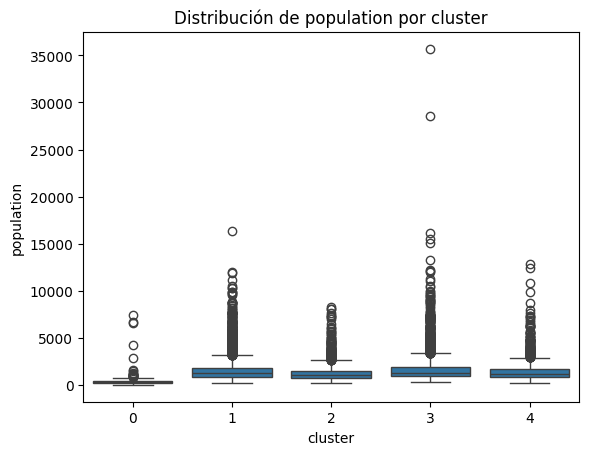

In [24]:
print_heading('Población')

plt.figure()
sns.boxplot(x='cluster', y='population', data=df)
plt.title(f'Distribución de population por cluster')
plt.show()

> ℹ Acá vemos que el cluster 0 presenta menores niveles de población, mientras que el resto muestra valores similares con alta dispersión, especialmente en el cluster 3.
>
> Dado que `population` es un conteo absoluto, su variabilidad y la presencia de outliers son esperables, lo que sugiere que no es una variable clave en la segmentación de los clusters.



## 3. Aplica DB-SCAN sobre el mismo dataset que utilizaste en el punto 2.

Realiza una interpretación de su aplicación y un análisis de los resultados obtenidos.

### DBSCAN

Density-Based Spatial Clustering of Applications with Noise (DBSCAN) es un algoritmo de clustering basado en densidad.

La idea principal es que forma clusters indentificando zonas donde los datos están muy concentrados, en lugar de dividir el espacio de manera uniforme.

A diferencia de otros métodos, DBSCAN no obliga a que todos los puntos pertenezcan a un cluster, sino que también puede detectar outliers.

---

**Parámetros principales**

- eps (epsilon): es la distancia máxima para considerar que dos puntos son vecinos.
- min_samples: es la cantidad mínima de puntos dentro de `eps` para que un punto sea considerado núcleo.

---
**Comparación con K-means**

K-means:
- Necesita definir la cantidad de clusters (k)
- Es más rápido y simple

DBSCAN:
- No necesita k
- Detecta ruido
- Funciona mejor con estructuras complejas

Entonces, en resumen:

DBSCAN es útil cuando no sabemos cuántos clusters hay y queremos que los grupos se formen de manera más “natural”, basándose en la densidad de los datos. Sin embargo, su rendimiento depende bastante de elegir bien sus parámetros, lo que puede requerir experimentación.

### Determinación de Parámetros para DBSCAN

 🟦 DETERMINANDO PARÁMETROS PARA DBSCAN: GRAFICANDO DISTANCIAS AL K-ÉSIMO VECINO




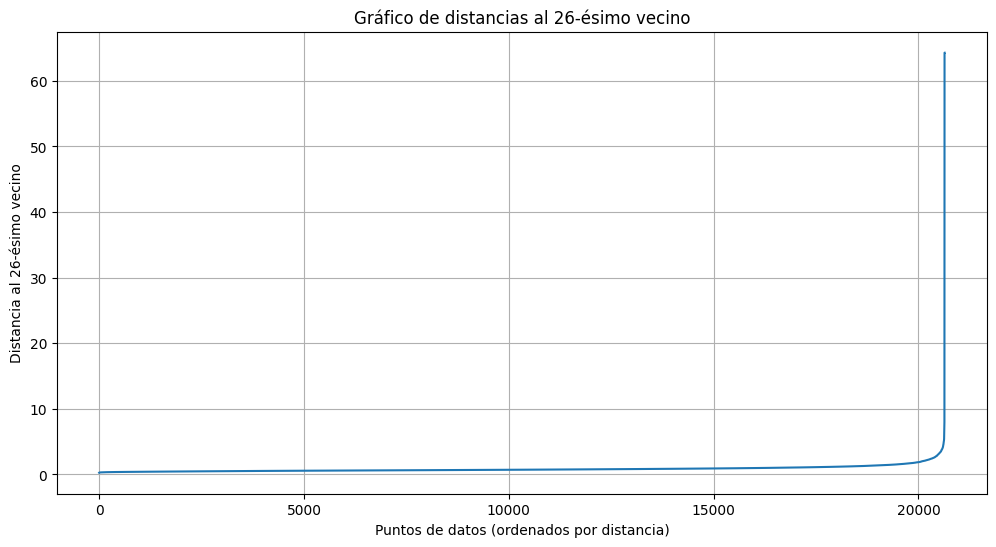

-> En este gráfico, busca el 'codo' que indica un buen valor para 'eps'. Un valor de 'min_samples' de 26 fue utilizado para calcular las distancias.


In [25]:
print_heading('Determinando parámetros para DBSCAN: Graficando distancias al k-ésimo vecino')

# min_samples es el "k" para el k-distance graph
# Una heurística común es 2 * número de dimensiones para datos de alta dimensión
# Aquí tenemos 13 características en X.
min_samples = X.shape[1] * 2 # 2 * 13 = 26

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ordenar las distancias para el gráfico
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title(f'Gráfico de distancias al {min_samples}-ésimo vecino')
plt.xlabel('Puntos de datos (ordenados por distancia)')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino')
plt.grid(True)
plt.show()

print(f"-> En este gráfico, busca el 'codo' que indica un buen valor para 'eps'. Un valor de 'min_samples' de {min_samples} fue utilizado para calcular las distancias.")

El gráfico de distancias al k-ésimo vecino (`k` siendo `min_samples`) nos ayuda a encontrar un valor adecuado para `eps`. Busca un punto donde la curva del gráfico tiene un cambio abrupto de pendiente (el "codo"). Este punto es a menudo un buen candidato para `eps`. Para `min_samples`, se puede usar la heurística de `2 * número_de_características` o experimentar con valores cercanos a este.

In [31]:
from sklearn.cluster import DBSCAN

# Basado en el gráfico anterior, eligimos un valor para eps.
eps_chosen = 3.5

print_heading(f'Aplicando DBSCAN con eps={eps_chosen} y min_samples={min_samples}')

dbscan = DBSCAN(eps=eps_chosen, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X)

df['dbscan_cluster'] = dbscan_labels

# Número de clusters encontrados (excluyendo el ruido, que es -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# Número de puntos de ruido
n_noise = list(dbscan_labels).count(-1)

print(f"-> Número estimado de clusters: {n_clusters}")
print(f"-> Número estimado de puntos de ruido: {n_noise}")

print("\n-> Distribución de puntos por cluster (incluyendo ruido -1):")
print(df['dbscan_cluster'].value_counts())

print("\n-> Vista aleatoria del dataset con clusters DBSCAN asignados: ")
display(df.sample(10))

 🟦 APLICANDO DBSCAN CON EPS=3.5 Y MIN_SAMPLES=26


-> Número estimado de clusters: 3
-> Número estimado de puntos de ruido: 29

-> Distribución de puntos por cluster (incluyendo ruido -1):
dbscan_cluster
 1    15675
 2     2649
 0     2287
-1       29
Name: count, dtype: int64

-> Vista aleatoria del dataset con clusters DBSCAN asignados: 


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,cluster,dbscan_cluster
17439,-120.45,34.63,32.0,1840.0,309.0,828.0,333.0,4.5486,172400.0,NEAR OCEAN,4,2
12081,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,160800.0,<1H OCEAN,3,1
11434,-117.97,33.65,26.0,2379.0,336.0,988.0,346.0,5.3674,339300.0,<1H OCEAN,3,1
2690,-115.52,32.97,24.0,1617.0,366.0,1416.0,401.0,1.9750,66400.0,INLAND,1,1
1663,-121.93,37.93,16.0,2169.0,262.0,877.0,245.0,6.6049,312600.0,INLAND,1,1
3631,-118.43,34.23,35.0,2049.0,390.0,1286.0,385.0,4.4432,181500.0,<1H OCEAN,3,1
19525,-121.00,37.64,52.0,530.0,177.0,325.0,158.0,1.1875,90600.0,INLAND,0,1
13185,-117.76,33.94,40.0,1092.0,213.0,457.0,190.0,5.1165,184200.0,<1H OCEAN,3,1
2808,-119.02,35.42,40.0,1089.0,226.0,520.0,218.0,2.2727,67200.0,INLAND,1,1
20182,-119.14,34.29,17.0,2754.0,577.0,1349.0,533.0,3.1618,154200.0,<1H OCEAN,3,1


### Análisis descriptivo de clusters

In [32]:
print_heading('Análisis Descriptivo de los Clusters DBSCAN')

# Excluyo la columna 'cluster' de KMeans para evitar confusión si se quisiera hacer un promedio
# y 'ocean_proximity' que no es numérica y ya se manejó con one-hot encoding en X
dbscan_cluster_description = df.groupby('dbscan_cluster').mean(numeric_only=True)
display(dbscan_cluster_description.round(2))

 🟦 ANÁLISIS DESCRIPTIVO DE LOS CLUSTERS DBSCAN




,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,cluster
dbscan_cluster,,,,,,,,,,
-1,-119.97,35.72,37.34,334.76,96.48,997.52,56.07,6.93,278641.52,0.00
0,-122.26,37.80,37.73,2496.84,514.16,1231.92,489.25,4.16,258951.11,1.92
1,-119.22,35.47,27.18,2667.63,540.56,1466.24,501.29,3.80,191910.29,2.02
2,-119.33,34.74,29.31,2592.33,539.25,1356.08,502.92,4.01,249531.30,3.83


> El algoritmo DBSCAN nos permitió identificar tres grupos principales de observaciones junto con un conjunto de puntos considerados ruido.
>
> Los clusters presentan diferencias principalmente en el ingreso medio, la densidad poblacional y el valor de las viviendas.
>
> En particular, se observa que mayores ingresos tienden a asociarse con mayores valores de vivienda, aunque existen excepciones detectadas como ruido. Además, uno de los clusters agrupa zonas más densas y de menor ingreso, mientras que otros representan áreas con mejores condiciones económicas.

 🟦 VISUALIZACIÓN DE CLUSTERS DBSCAN: MEDIAN INCOME




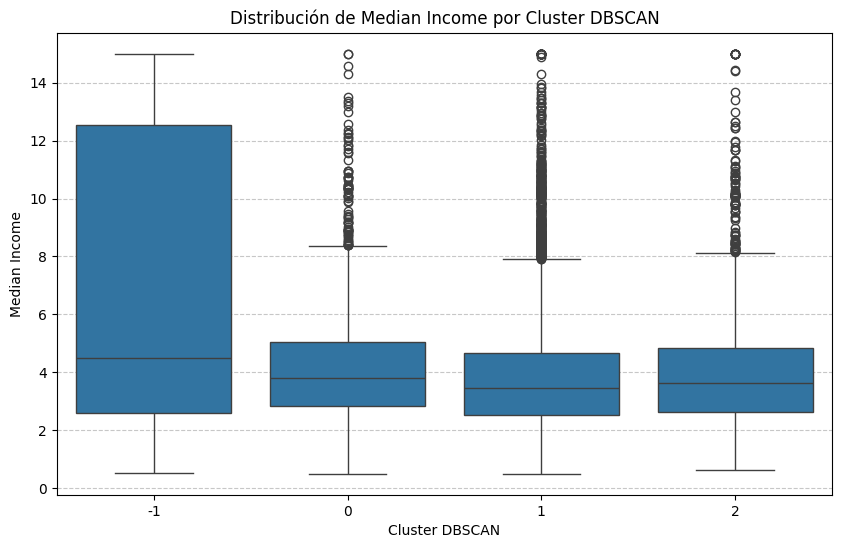

 🟦 VISUALIZACIÓN DE CLUSTERS DBSCAN: MEDIAN HOUSE VALUE




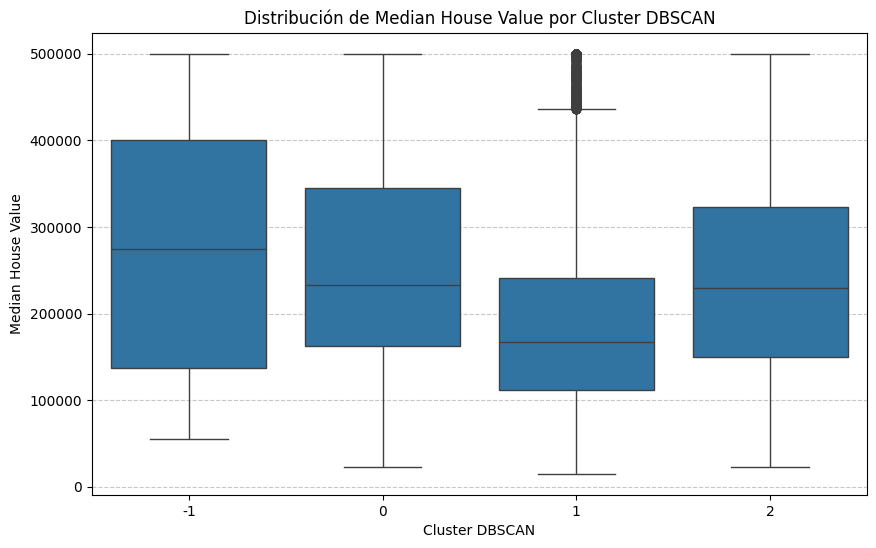

 🟦 VISUALIZACIÓN DE CLUSTERS DBSCAN: POPULATION




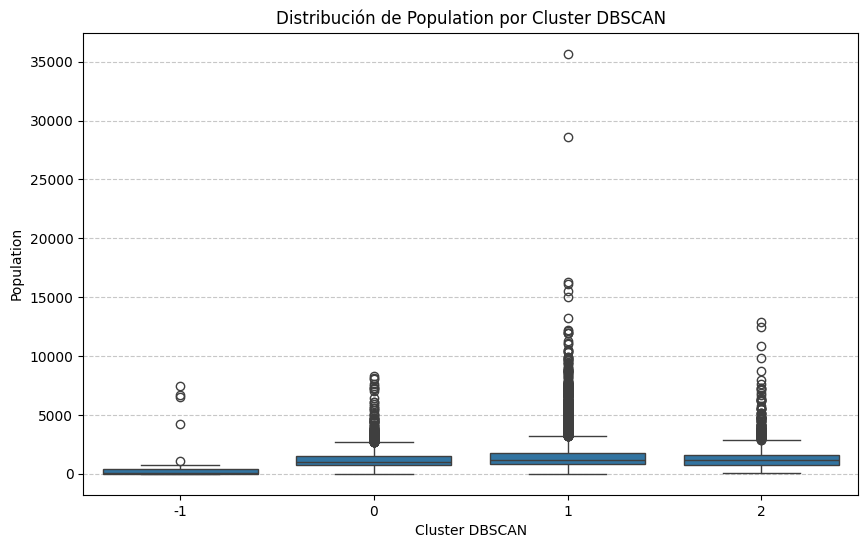

In [33]:
print_heading('Visualización de Clusters DBSCAN: Median Income')

plt.figure(figsize=(10, 6))
sns.boxplot(x='dbscan_cluster', y='median_income', data=df)
plt.title('Distribución de Median Income por Cluster DBSCAN')
plt.xlabel('Cluster DBSCAN')
plt.ylabel('Median Income')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print_heading('Visualización de Clusters DBSCAN: Median House Value')

plt.figure(figsize=(10, 6))
sns.boxplot(x='dbscan_cluster', y='median_house_value', data=df)
plt.title('Distribución de Median House Value por Cluster DBSCAN')
plt.xlabel('Cluster DBSCAN')
plt.ylabel('Median House Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print_heading('Visualización de Clusters DBSCAN: Population')

plt.figure(figsize=(10, 6))
sns.boxplot(x='dbscan_cluster', y='population', data=df)
plt.title('Distribución de Population por Cluster DBSCAN')
plt.xlabel('Cluster DBSCAN')
plt.ylabel('Population')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

> Observando estos boxplots, podemos ver que las principales diferencias entre los clusters se encuentran en variables relacionadas con la densidad, como la población y menor valor de vivienda, lo que podría asociarse a zonas más densamente habitadas.
>
> Por otro lado, los valores de ingreso se mantienen relativamente similares entre clusters, lo que sugiere que esta variable no fue determinante en la formación de los grupos. Finalmente, el conjunto de ruido presenta una alta dispersión en todas las variables, confirmando su carácter atípico.

### Visualización de clusters

 🟦 VISUALIZACIÓN GEOGRÁFICA DE CLUSTERS DBSCAN




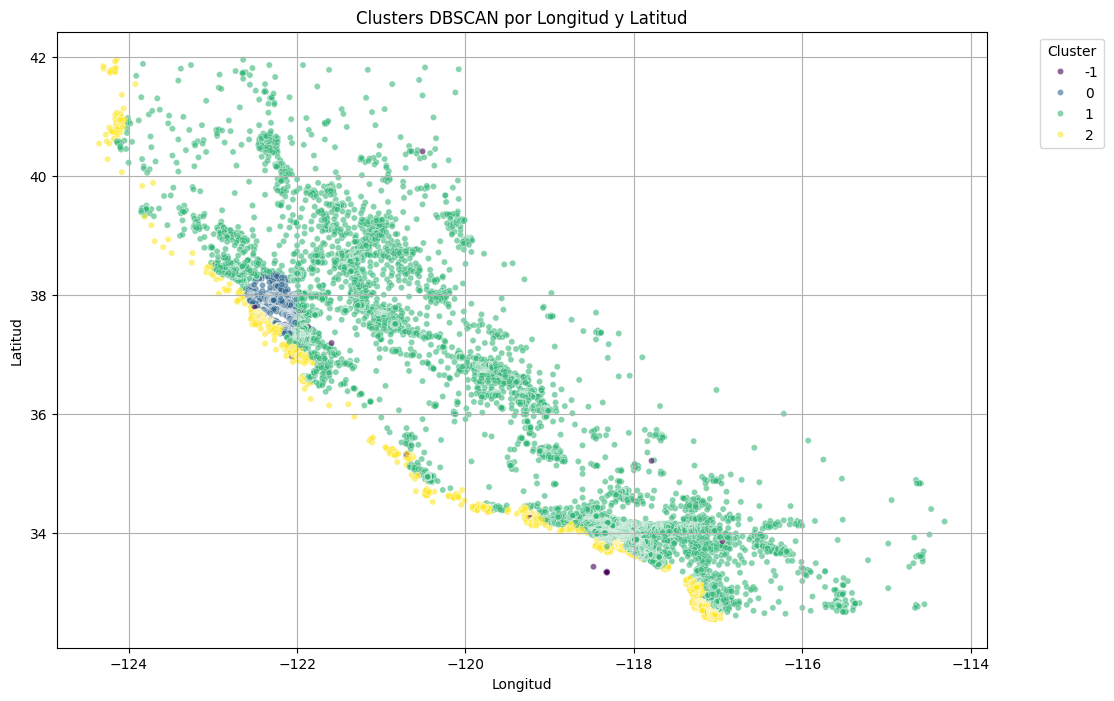

In [34]:
print_heading('Visualización Geográfica de Clusters DBSCAN')

plt.figure(figsize=(12, 8))
sns.scatterplot(x='longitude', y='latitude', hue='dbscan_cluster', data=df, palette='viridis', s=20, alpha=0.6)
plt.title('Clusters DBSCAN por Longitud y Latitud')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

>  La visualización geográfica de los clusters muestra que DBSCAN logra identificar agrupaciones que respetan la distribución espacial de los datos. En particular, se observa un cluster alineado con la zona costera, otro que abarca la mayor parte del interior, y uin grupo más concentrado en una región específica de alta densidad.
>
>Esto evidencia que el algoritmo está capturando patrones basados en la proximidad geográfica y la densidad de observaciones. Además, la presencia de puntos clasificados como ruido indica la existencia de observaciones aisladas que no forman parte de ninguna región densa. En conjunto, estos resultados son consistentes con el funcionamiento esperado de DBSCAN.

### Interpretación y Conclusiones

# NO OLVIDES

Agregar tus conclusiones y referencias.